### IMPORT DATA

In [1]:
import pandas as pd

#IMPORT DEFINITIVE DATA
filepath_life='life-exp.csv'
life_df= pd.read_csv(filepath_life)
# life_df.head()

In [2]:
#COL NAMES
life_df.columns

Index(['Country Name', 'Country Code', 'Region', 'IncomeGroup', 'Year',
       'Life Expectancy World Bank', 'Prevelance of Undernourishment', 'CO2',
       'Health Expenditure %', 'Education Expenditure %', 'Unemployment',
       'Corruption', 'Sanitation', 'Injuries', 'Communicable',
       'NonCommunicable'],
      dtype='str')

In [3]:
#DROP UNWANTED COLS
life_df=life_df.drop(columns=['Region','Prevelance of Undernourishment',
                              'Corruption', 'Sanitation'])

Removed columns that were either not of interest or had a majority missing values.

In [4]:
#WHICH YEARS
life_df['Year'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

See the distinct years that are present in the data

In [5]:
#RENAME TO MATCH 
life_df=life_df.rename(columns={'Country Code': 'Code'})

Change this to match code column in gdp dataset. Going to merge on code because there is less likely to be discrepencies between code compared to country names.

In [6]:
#DATATYPES
life_df.dtypes

Country Name                      str
Code                              str
IncomeGroup                       str
Year                            int64
Life Expectancy World Bank    float64
CO2                           float64
Health Expenditure %          float64
Education Expenditure %       float64
Unemployment                  float64
Injuries                      float64
Communicable                  float64
NonCommunicable               float64
dtype: object

Inspect data types

In [7]:
#DIM LIFE DF
life_df.shape

(3306, 12)

In [8]:
#READ IN GDP DF
filepath_gdp='gdp.csv'
gdp_df= pd.read_csv(filepath_gdp)
#gdp_df.head()

In [9]:
#INSPECT COLS
gdp_df.columns

Index(['Country Name', 'Code', '1960', '1961', '1962', '1963', '1964', '1965',
       '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974',
       '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', 'Unnamed: 65'],
      dtype='str')

GDP data had distinct years as columns. There is also more data for additional years.

In [10]:
print(gdp_df.columns.tolist())

['Country Name', 'Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', 'Unnamed: 65']


In [11]:
#DROP UNWNATED YEARS
gdp_df=gdp_df.drop(columns=['1960', '1961', '1962', '1963', '1964', '1965',
       '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974',
       '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000'])

In [12]:
gdp_df = gdp_df.drop(columns=['Unnamed: 65'],errors='ignore')

Removing years not present in life expectancy data. removing 1960-2000

##### CONVERT FROM WIDE TO LONG FROMAT

In [13]:
#WIDE TO LONG FORMAT
gdp_long = gdp_df.melt(id_vars=['Code', 'Country Name'],   
    var_name='Year', value_name='GDP')

#gdp_long.head()

Change from wide to long format for the merge. Head checks that the change was sucessful and looks as it should.

In [14]:
#DATATYPES
gdp_long.dtypes

Code                str
Country Name        str
Year                str
GDP             float64
dtype: object

The columns datatypes match between the 2 dataframes for the merge.

In [15]:
#CONVERT YEAR TO INT
gdp_long['Year']=gdp_long['Year'].astype(int)

To match the year column datatype in life_df

In [16]:
#DIM GDP DF
gdp_long.shape

(5320, 4)

### LEFT MERGE DATA

In [17]:
# LEFT MERGE
merged_df = pd.merge(life_df, gdp_long, on=['Code', 'Year'], how='left', indicator=True)
merged_df.head()

,Country Name_x,Code,IncomeGroup,Year,Life Expectancy World Bank,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Injuries,Communicable,NonCommunicable,Country Name_y,GDP,_merge
0,Afghanistan,AFG,Low income,2001,56.308,730.0,NaN,NaN,10.809000,2179727.10,9689193.70,5795426.38,Afghanistan,NaN,both
1,Angola,AGO,Lower middle income,2001,47.059,15960.0,4.483516,NaN,4.004000,1392080.71,11190210.53,2663516.34,Angola,8.936064e+09,both
2,Albania,ALB,Upper middle income,2001,74.288,3230.0,7.139524,3.4587,18.575001,117081.67,140894.78,532324.75,Albania,3.922101e+09,both
3,Andorra,AND,High income,2001,NaN,520.0,5.865939,NaN,NaN,1697.99,695.56,13636.64,Andorra,1.546926e+09,both
4,United Arab Emirates,ARE,High income,2001,74.544,97200.0,2.484370,NaN,2.493000,144678.14,65271.91,481740.70,United Arab Emirates,1.033116e+11,both


In [18]:
#COMPARING COUNTRIES IN LIFE EXP DF
print(len(set(life_df['Code']) - set(gdp_long['Code'])))

0


Shows how many country codes from GDP dataset are in the life expectancy dataset. The output is 0 indicating all countries in the life expectancy df have a matching country name in the GDP df.

Since we are doing a left merge we expect the same number of rows as the life df. The dimensions confirm this number. We also expected 3 more columns from the column counts in the life expectancy df. This is because we are adding GDP as a column and country name is added again from the gdp dataset. The third column is the indicator/merge column. The dimensions confirm the merge was sucessful.

In [19]:
#LIFE EXP DF DIM
life_df.shape

(3306, 12)

In [20]:
#GDP DF DIM
gdp_long.shape

(5320, 4)

In [21]:
#mean of indicator column
(merged_df['_merge'] == 'both').mean()

np.float64(1.0)

The line of code calculates the proportion of rows that successfully matched between life_df and gdp_long during the merge. The expression creates a Boolean array where each row is marked as True if the (Code, Year) combination exists in both datasets and False otherwise. When .mean() is applied, Python treats True values as 1 and False values as 0, so the result represents the percentage of rows that matched. This serves as a clean validation of the merge because it checks only whether the keys aligned correctly, independent of whether the GDP values themselves are missing. A result of 1 indicates that every row in life_df found a corresponding match in gdp_long, confirming that the merge was structurally successful.

In [22]:
merged_df.columns

Index(['Country Name_x', 'Code', 'IncomeGroup', 'Year',
       'Life Expectancy World Bank', 'CO2', 'Health Expenditure %',
       'Education Expenditure %', 'Unemployment', 'Injuries', 'Communicable',
       'NonCommunicable', 'Country Name_y', 'GDP', '_merge'],
      dtype='str')

In [23]:
#COLUMN CLEANING
merged_df=merged_df.rename(columns={'Country Name_x': 'Country Name'})
merged_df = merged_df.drop(columns=['Country Name_y', '_merge'], errors='ignore')
merged_df=merged_df.rename(columns={'Life Expectancy World Bank': 'Life Expectancy'})

Keep Country Name from life-exp df as official name and drop the other country name as well as the _merge column we used to check if the merge was sucessful. Rename Life-exp for simplicity.

In [24]:
!pip3 install pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [25]:
#Export data
merged_df.to_parquet("merged_data.parquet")


Export to a parquet file to preserve datatypes.

### MISSING VALUES

In [26]:
#missing value counts
merged_df.isna().sum()

Country Name                  0
Code                          0
IncomeGroup                   0
Year                          0
Life Expectancy             188
CO2                         152
Health Expenditure %        180
Education Expenditure %    1090
Unemployment                304
Injuries                      0
Communicable                  0
NonCommunicable               0
GDP                          44
dtype: int64

total counts of missing values

In [27]:
#missing value proportion
merged_df.isna().sum()/len(merged_df)

Country Name               0.000000
Code                       0.000000
IncomeGroup                0.000000
Year                       0.000000
Life Expectancy            0.056866
CO2                        0.045977
Health Expenditure %       0.054446
Education Expenditure %    0.329704
Unemployment               0.091954
Injuries                   0.000000
Communicable               0.000000
NonCommunicable            0.000000
GDP                        0.013309
dtype: float64

total proportions of missing values. Education expenditure as a concerningly high missing percentage. The others look ok.

In [28]:
#IMPUTE W FORWARD/ BACKWARD FILL
cols_to_fill = ['Life Expectancy', 'CO2',
       'Health Expenditure %', 'Education Expenditure %', 'Unemployment',
       'Injuries', 'Communicable', 'NonCommunicable', 'GDP']

merged_df = merged_df.sort_values(['Code', 'Year'])

merged_df[cols_to_fill] = (
    merged_df
    .groupby('Code')[cols_to_fill]
    .transform(lambda x: x.interpolate().ffill().bfill())
)

This step imputes missing values for key numeric variables within each country by first sorting observations by country and year. Linear interpolation is used to estimate values between known years, followed by forward and backward filling to replace any remaining missing values with the nearest available observation from that same country. Linear interpolation is a method used to estimate a missing value by assuming a straight-line change between two known values.

In [29]:
#missing value counts
merged_df.isna().sum()

Country Name                 0
Code                         0
IncomeGroup                  0
Year                         0
Life Expectancy            152
CO2                        152
Health Expenditure %       133
Education Expenditure %    171
Unemployment               304
Injuries                     0
Communicable                 0
NonCommunicable              0
GDP                          0
dtype: int64

In [30]:
# WHICH COUNTRIES HAVE MISSING FOR ALL YEARS
for col in cols_to_fill:
    print(f"\n{col}")
    print(
        merged_df.groupby('Code')[col]
        .apply(lambda x: x.isna().all())
        .loc[lambda x: x]
    )


Life Expectancy
Code
AND    True
ASM    True
MCO    True
MHL    True
MNP    True
NRU    True
SMR    True
TUV    True
Name: Life Expectancy, dtype: bool

CO2
Code
ASM    True
BMU    True
GRL    True
GUM    True
MCO    True
MNP    True
PRI    True
SMR    True
Name: CO2, dtype: bool

Health Expenditure %
Code
ASM    True
BMU    True
GRL    True
GUM    True
MNP    True
PRI    True
SOM    True
Name: Health Expenditure %, dtype: bool

Education Expenditure %
Code
BIH    True
GNQ    True
GUM    True
LBY    True
MNE    True
MNP    True
NGA    True
SOM    True
TUV    True
Name: Education Expenditure %, dtype: bool

Unemployment
Code
AND    True
ASM    True
ATG    True
BMU    True
DMA    True
GRD    True
GRL    True
KIR    True
MCO    True
MHL    True
MNP    True
NRU    True
PLW    True
SMR    True
SYC    True
TUV    True
Name: Unemployment, dtype: bool

Injuries
Series([], Name: Injuries, dtype: bool)

Communicable
Series([], Name: Communicable, dtype: bool)

NonCommunicable
Series([], Name: N

This step checks each selected variable for countries where all yearly observations are missing. It groups the data by country code and identifies cases where a variable contains only missing values across the full time period, helping determine which countries may need to be removed or require additional imputation.

In [31]:
# DROP COUNTRIES WHERE LIFE EXP MISSING ALL YEARS
drop_countries = (
    merged_df.groupby('Code')['Life Expectancy']
    .apply(lambda x: x.isna().all())
    .loc[lambda x: x]
    .index
)

merged_df = merged_df[~merged_df['Code'].isin(drop_countries)]

This step identifies countries where Life Expectancy is missing for every year in the dataset and removes them from the analysis. Since Life Expectancy is the response variable, countries with no observed values cannot contribute to the model and are excluded to improve data quality and reliability.

In [32]:
#missing value counts
merged_df.isna().sum()

Country Name                 0
Code                         0
IncomeGroup                  0
Year                         0
Life Expectancy              0
CO2                         76
Health Expenditure %        95
Education Expenditure %    133
Unemployment               152
Injuries                     0
Communicable                 0
NonCommunicable              0
GDP                          0
dtype: int64

In [33]:
# IMPUTE REMAINING MISSING
remaining_cols = [
    'CO2',
    'Health Expenditure %',
    'Education Expenditure %',
    'Unemployment'
]

for col in remaining_cols:
    merged_df[col] = merged_df.groupby('IncomeGroup')[col].transform(
        lambda x: x.fillna(x.median())
    )

This step imputes the remaining missing values for key predictor variables by replacing them with the median value of countries within the same income group. Using income-group medians preserves similarities between comparable economies and provides a more reliable estimate than using a single overall average. While this approach improves model completeness and reduces data loss, imputed values may reduce variability and should be considered when interpreting predictor importance and model performance. Countries with imputed values become more similar to others in their income group, which can slightly weaken true country-specific differences.

In [34]:
#missing value counts
merged_df.isna().sum()

Country Name               0
Code                       0
IncomeGroup                0
Year                       0
Life Expectancy            0
CO2                        0
Health Expenditure %       0
Education Expenditure %    0
Unemployment               0
Injuries                   0
Communicable               0
NonCommunicable            0
GDP                        0
dtype: int64

In [35]:
merged_df['Code'].nunique()

166

Missing values are good now and after imputation and removing we have 166 countries data to work with.

### RANDOM FOREST

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#IMPORT PKGS
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score

In [38]:
#SPLIT BY COUNTRY
countries = merged_df['Code'].dropna().unique().tolist()

train_countries, test_countries = train_test_split(
    countries,test_size=0.20,random_state=42)

This code creates a country-level train-test split by extracting unique country codes and dividing them into 80% training and 20% testing groups. Splitting by country instead of individual rows prevents the same country from appearing in both datasets, reducing data leakage and providing a more reliable model evaluation.

In [39]:
#TRAIN/TEST SPLIT
train_df = merged_df[merged_df['Code'].isin(train_countries)]
test_df = merged_df[merged_df['Code'].isin(test_countries)]

train_df = merged_df[merged_df['Code'].isin(train_countries)]
test_df = merged_df[merged_df['Code'].isin(test_countries)]

This code creates separate training and testing datasets by selecting rows based on whether each country belongs to the training or testing group.

In [40]:
#DEFINE PREDICTOR/ RESPONSE
predictors = ['GDP','CO2','Health Expenditure %','Education Expenditure %','Unemployment','Injuries']

X_train = train_df[predictors]
y_train = train_df['Life Expectancy']

In [41]:
#FIT MODEL
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

Fit random forest model. The arguments reduce the tree complexity to prevent overfitting.

In [42]:
#PREDICTIONS
X_test = test_df[predictors]
y_test = test_df['Life Expectancy']

y_pred = rf.predict(X_test)

In [43]:
#MODEL PERFORMANCE
print("Country-Based Test R²:", r2_score(y_test, y_pred))
print("Country-Based RMSE:", root_mean_squared_error(y_test, y_pred))

Country-Based Test R²: 0.6791970215860922
Country-Based RMSE: 5.135772664280161


R² = 0.68
This means the model explains about 68% of the variation in Life Expectancy.
That indicates an extremely strong fit between your predictors and life expectancy.

RMSE = 5.14
This means the model’s predictions are off by about 5.14 years of life expectancy on average.

In [44]:
#CROSS VALIDATION 
X = merged_df[predictors]
y = merged_df['Life Expectancy']
groups = merged_df['Code']

group_kfold = GroupKFold(n_splits=5)

This sets up 5-fold Group K-Fold cross-validation, which splits the data into five groups while keeping each country entirely in one fold to prevent data leakage.

In [45]:
#CV SCORES
cv_scores = cross_val_score(rf,X,y,
    cv=group_kfold,
    groups=groups,
    scoring='r2')

print("Group CV R² Scores:", cv_scores)
print("Average Group CV R²:", cv_scores.mean())

Group CV R² Scores: [0.52382161 0.70786268 0.5389848  0.4579216  0.65829891]
Average Group CV R²: 0.5773779204791072


This runs cross-validation on the Random Forest model using the grouped folds and calculates an R² score for each fold. Using country groups ensures the model is tested on completely unseen countries. The average CV R2 means that across different validation splits, your Random Forest explains about 80.4% of the variation in Life Expectancy. 

In [46]:
#VARIABLE IMPORTANCE
importance_df = pd.DataFrame({
    'Variable': predictors,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                  Variable  Importance
1                      CO2    0.318616
5                 Injuries    0.303456
4             Unemployment    0.112933
0                      GDP    0.105373
2     Health Expenditure %    0.101051
3  Education Expenditure %    0.058571


This step calculates and ranks the importance of each predictor in the Random Forest model by measuring how much each variable contributes to reducing prediction error. The results are sorted from most important to least important to identify which factors have the strongest influence on predicting life expectancy.

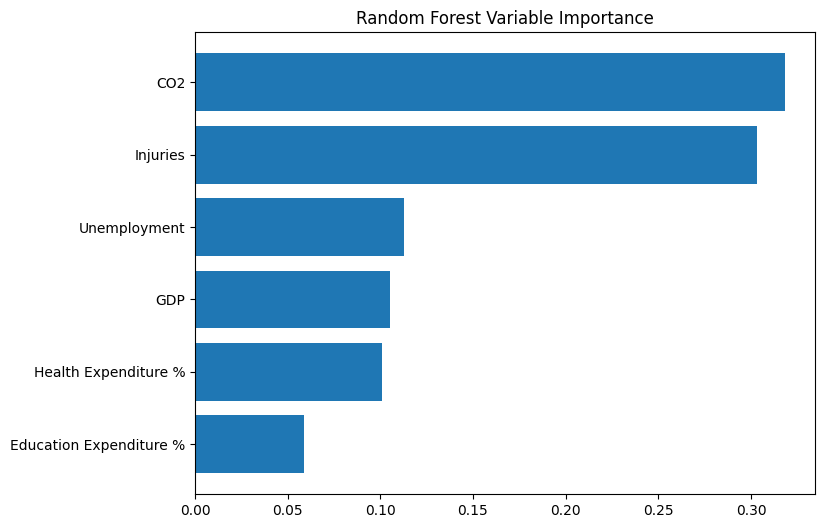

In [47]:
#VARIABLE IMPORTNACE PLOT
plt.figure(figsize=(8,6))
plt.barh(
    importance_df['Variable'],
    importance_df['Importance']
)
plt.gca().invert_yaxis()
plt.title("Random Forest Variable Importance")
plt.savefig('var_imp_plot.png')
plt.show()

The bar chart of Random Forest variable importance scores visually compares which predictors contribute most to predicting life expectancy. The x-axis represents the importance score, which measures how much each variable helps reduce prediction error across the model’s decision trees. Higher values indicate stronger predictive importance, but these scores do not show the direction of the relationship, meaning they do not indicate whether a variable increases or decreases life expectancy.

### PDP Plots

A Partial Dependence Plot (PDP) is a visualization used in machine learning to show how a single predictor variable affects the model’s predicted outcome, while averaging out the influence of all other variables. It isolates the relationship between one feature and the response. By examining the shape of the curve, you can understand whether the relationship is positive or negative, as well as whether it is linear or nonlinear, and identify patterns

In [ ]:
#IMPORT PKGS
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

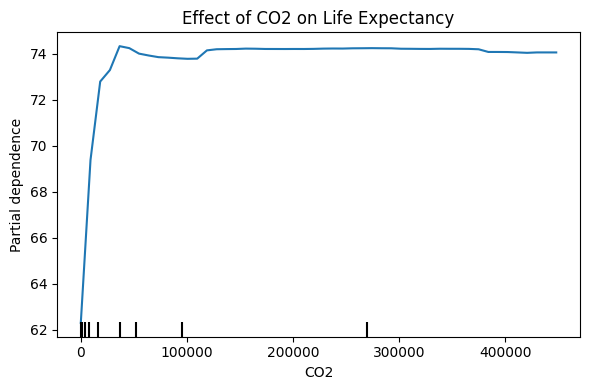

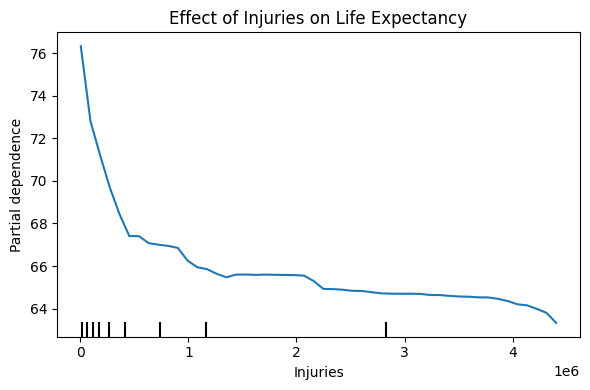

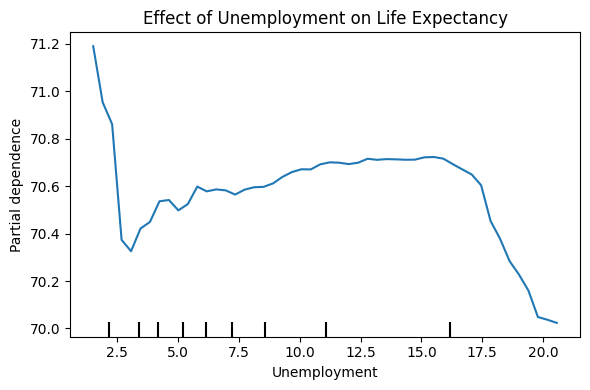

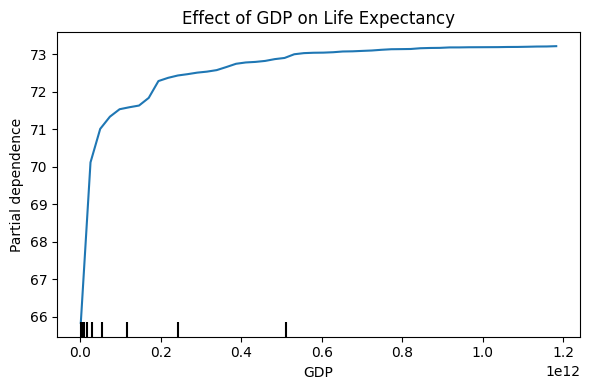

In [50]:
#LIST TOP PREDICTORS
imp_features = ['CO2', 'Injuries', 'Unemployment', 'GDP']

#LOOP SHOWING PDP PLOT FOR EACH FEATURE
for feature in imp_features:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    PartialDependenceDisplay.from_estimator(
        rf,
        X_train,
        features=[feature],
        grid_resolution=50,
        ax=ax
    )
    
    #TITLE
    plt.title(f"Effect of {feature} on Life Expectancy")
    plt.tight_layout()
   
   #CREATE FILENAMES
    filename = f"pdp_{feature.replace(' ', '_').replace('%','pct')}.png"

     #SAVE FIGS
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

The code loops through each variable (top 4 most important from the variable importance plot), creates a separate plot, and uses the model to estimate how changes in that variable affect predicted life expectancy while holding all other variables constant. Each iteration produces an individual visualization showing the relationship between one predictor and the outcome.
The result is a set of plots that illustrate how each key variable influences life expectancy across its range of values.

In depth code explaination of PDP plot loop steps.
    The function takes the trained model (rf) and training data (X_train)
    It selects one feature at a time
    It creates 50 evenly spaced values across that feature’s range
    For each value:
        The feature is set to that value for all observations
        The model makes predictions
        The predictions are averaged
This produces a curve showing the average predicted life expectancy as that feature changes, while all other variables are effectively held constant.

#### PDP Interpretations

CO2 v. Life Expectancy

CO₂ was the most important feature in the Random Forest variable importance plot. The PDP shows that increases in CO₂ are associated with a sharp rise in predicted life expectancy at low levels, followed by a plateau, indicating a nonlinear diminishing returns relationship. While this may seem counterintuitive, one explaination could be proxy effect—countries with higher CO₂ emissions tend to be more industrialized, wealthier, and have better healthcare systems. Further analysis would be needed to confirm this.

Injuries v Life Expectancy

Injuries (measured as Disability-Adjusted Life Years, or DALYs lost due to injuries) was the 2nd most important features in the Random Forest model. The PDP shows a strong negative relationship, where increases in injury-related DALYs are associated with a sharp decline in predicted life expectancy, followed by a more gradual decrease at higher levels. This indicates a nonlinear relationship.
This result is intuitive, as higher DALYs from injuries represent greater loss of healthy life years within a population, which directly aligns with lower life expectancy.

Unemployment v Life Expectancy
Unemployment (measured as the percentage of the labor force that is without work but actively seeking employment) was the 3rd most important predictor in the Random Forest model. The PDP shows a nonlinear, non-monotonic relationship with life expectancy. At low unemployment levels, increases are associated with a decline in predicted life expectancy, followed by a slight increase and plateau at moderate levels. However, at higher unemployment rates, life expectancy declines again. This suggests a complex relationship, where both very low and very high unemployment may be associated with lower life expectancy, while moderate levels correspond to relatively stable conditions.

GDP v Life Expectancy
GDP was one of the most important predictors in the Random Forest model. The PDP shows a strong positive relationship, where increases in GDP are associated with substantial gains in predicted life expectancy at lower levels, followed by a gradual plateau at higher levels. This indicates a nonlinear, diminishing returns relationship. This result is intuitive, increases in GDP at lower levels significantly boost life expectancy. One explaination for this could be improvements in infrastructure, healthcare access, and overall living conditions. However, beyond a certain point, additional economic growth yields smaller gains, suggesting that once basic needs and systems are established, further increases in GDP have a limited impact on life expectancy.